In [1]:
from dataset import *
from evaluate import *
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
from sklearn.metrics import balanced_accuracy_score

cpu


In [2]:
class NCImageDataset(Dataset):
    def __init__(self, root_dir):
        """
        Args:
            root_dir (str): Root directory containing the images organized into 'positive' and 'negative' folders.
        """
        self.samples = []  # List to store tuples of (file_path, class_label)
        
        for root, dirs, files in os.walk(root_dir):
            for file in files:
                if file == ".DS_Store":
                    continue  # Skip system files
                file_path = os.path.join(root, file)
                folder_name = os.path.basename(root)
                if folder_name == "negative":
                    class_label = 0
                elif folder_name == "positive":
                    class_label = 1
                else:
                    continue  # Skip if folder name is not 'positive' or 'negative'
                
                self.samples.append((file_path, class_label))
    
    def __len__(self):
        """Returns the total number of samples."""
        return len(self.samples)
    
    def __getitem__(self, idx):
        """
        Args:
            idx (int): Index of the sample to retrieve.
        
        Returns:
            image (Tensor): The image as a PyTorch tensor.
            class_label (int): The class label (0 for negative, 1 for positive).
        """
        file_path, class_label = self.samples[idx]
        
        # Read image using rasterio
        with rio.open(file_path) as src:
            image = src.read([1,2,3])  # Reads the image as a NumPy array (C, H, W)
            image = torch.tensor(image)  # Convert to PyTorch tensor
        
        transform  = transforms.Compose([
                            transforms.ToPILImage(),
                            transforms.RandomHorizontalFlip(),
                            transforms.RandomRotation(degrees=90),
#                             transforms.CenterCrop(size=224),
                            transforms.ToTensor()
        ])
        sample = {'image': transform(image),
                 'class_lbl': class_label,
                 'file_path': file_path}
        return sample


In [3]:
nc_sites = '/work/srs108/nc'
dataset = NCImageDataset(root_dir=nc_sites)

In [4]:
len(dataset)

0

In [18]:
# from collections import defaultdict
# from tqdm import tqdm

# def count_samples_by_location_and_class(dataset):
#     counts = defaultdict(lambda: {"positive": 0, "negative": 0})
    
#     # Check if the dataset is a Subset
#     if isinstance(dataset, torch.utils.data.Subset):
#         # Get the parent dataset and subset indices
#         parent_dataset = dataset.dataset
#         subset_indices = dataset.indices
#         samples = [(parent_dataset[i][0], parent_dataset[i][1]) for i in subset_indices]
#     else:
#         # Handle a standard dataset
#         samples = dataset.samples  # Assuming the dataset has a `samples` attribute

#     for file_path, class_label in tqdm(samples):
#         # Extract location from file path
#         location = file_path.split('/')[-3]
#         # Increment counts based on class label
#         if class_label == 0:
#             counts[location]["negative"] += 1
#         elif class_label == 1:
#             counts[location]["positive"] += 1

#     return counts

# # Example usage
# counts_by_location_and_class = count_samples_by_location_and_class(test_dataset)

# # Print counts
# for location, class_counts in counts_by_location_and_class.items():
#     print(f"Location: {location}, Positive: {class_counts['positive']}, Negative: {class_counts['negative']}")


In [19]:
val_ratio, test_ratio = 0.25, 0.25
indices = (range(len(dataset)))
batch_size = 16

train_indices, temp_indices = train_test_split(indices, test_size=(val_ratio + test_ratio), shuffle=True)
val_indices, test_indices = train_test_split(temp_indices, test_size=test_ratio/(val_ratio + test_ratio))
train_dataset = Subset(dataset, train_indices)
val_dataset = Subset(dataset, val_indices)
test_dataset = Subset(dataset, test_indices)

In [20]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

3704 1852 1853


In [21]:
# all_labels = [train_dataset[i]['class_lbl'] for i in tqdm(range(len(train_dataset)), position = 0, leave =True)]
# class_counts = np.bincount(all_labels)
# class_weights = 1.0 / class_counts 
# sample_weights = [class_weights[label] for label in all_labels]
# sample_weights = torch.tensor(sample_weights, dtype=torch.float)
# print(class_counts)

In [22]:
# torch.save((class_counts, class_weights, sample_weights), 'tk2_sampler_weights.pth')
class_counts, class_weights, sample_weights = torch.load('planet_binary.pth')

In [23]:
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

In [24]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet_pretrained = resnet50(pretrained=True)
        self.resnet_pretrained.conv1 = nn.Conv2d(3, 64, kernel_size=(3, 3),
                              stride=(2, 2),padding=(3, 3), bias=False)
        
        self.fc1 = nn.Linear(self.resnet_pretrained.fc.out_features, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 1)  # output size changed to 2
        self.dropout = nn.Dropout(p=0.35)
    def forward(self, image):
        img_features = self.resnet_pretrained(image)
        img_features = torch.flatten(img_features, 1)
        img_features = self.fc1(img_features)
        x = self.relu(img_features)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc3(x)
        return x

In [12]:
def test(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0
    running_acc = 0
    running_bacc = 0

    with torch.no_grad():
        for i, batch in tqdm(enumerate(dataloader)):
            x = batch['image'].float().to(device)
            y = batch['class_lbl'].float().to(device)

            output = model(x)
            output_binary = np.zeros(output.shape)
            output_binary[output.cpu().detach().numpy() >= 0] = 1 #if logit is greater than 0, classify as bloom
#             print(output_binary)

            #loss
            loss = criterion(output.squeeze(dim=1),y) #BCEwL
            running_loss += loss.item()

            #accuracy
            label = y.cpu().detach().numpy()
            acc = accuracy_score(label,output_binary)
            bacc = balanced_accuracy_score(label, output_binary)
            running_acc += acc
            running_bacc += bacc
            torch.cuda.empty_cache()
        
        return running_loss/len(dataloader), running_acc/len(dataloader), running_bacc/len(dataloader)

In [13]:
def train(model, dataloader, criterion, opt, epoch, device):
    running_acc = 0
    running_loss = 0
    running_bacc = 0
    model.train()

    for i, batch in tqdm(enumerate(dataloader)):
        try:
#             if 100 <= i+1 <=101: print(batch)
            x = batch['image'].float().to(device)
            y = batch['class_lbl'].float().to(device)
            
            output = model(x)
            output_binary = np.zeros(output.shape)
            output_binary[output.cpu().detach().numpy() >= 0] = 1 #if logit is greater than 0, classify as bloom

            #loss
            loss = criterion(output.squeeze(dim=1),y) #BCEwL
            running_loss += loss.item()

            #accuracy
            label = y.cpu().detach().numpy()

            acc = accuracy_score(label,output_binary)
            bacc = balanced_accuracy_score(label, output_binary)

            running_acc += acc
            running_bacc += bacc
            opt.zero_grad()
            loss.backward()
            opt.step()
            torch.cuda.empty_cache()
        
        except IndexError as e:
            print(f"\n❌ ERROR at Epoch {epoch}, Iteration {i+1}: {e}")
            print(f"Dataset length: {len(dataloader.dataset)}")
            print(f"Sampler indices length: {len(dataloader.sampler.indices) if hasattr(dataloader.sampler, 'indices') else 'N/A'}")
            exit(1)

        except Exception as e:
            print(f"\n❌ Unexpected Error at Iteration {i+1}: {e}")
            exit(1)

        
    return running_loss/len(dataloader), running_acc/len(dataloader), running_bacc/len(dataloader)

In [16]:
def main(model, epochs):
    opt = optim.Adam(model.parameters(), lr=1e-5)
    criterion = nn.BCEWithLogitsLoss().to(device)
    best_loss = 1e6
    patience = np.ceil(0.1 * epochs)
    trigger_times = 0
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [], 'train_bacc': [], 'val_bacc': []
    }

    for epoch in range(39, epochs + 1):
#         print(f"\n=== Epoch {epoch} ===")
#         print(f"Train dataset length: {len(train_loader.dataset)}")
#         print(f"Validation dataset length: {len(val_loader.dataset)}")

        if hasattr(train_loader, 'sampler') and hasattr(train_loader.sampler, 'indices'):
            print(f"Train sampler indices length: {len(train_loader.sampler.indices)}")

        try:
            train_loss, train_acc, train_bacc = train(model, train_loader, criterion, opt, epoch, device)
        except IndexError as e:
            print(f"IndexError in training at epoch {epoch}: {e}")
            print("Possible cause: Dataset length mismatch with indices.")
            exit(1)

        val_loss, val_acc, val_bacc = test(model, val_loader, criterion, device)

        if val_loss < best_loss:
            trigger_times = 0
            best_loss = val_loss
            best_model_weights = model.state_dict()
            torch.save(model.state_dict(), 'bal_edit2.pt')
        else:
            trigger_times += 1
            if trigger_times == patience:
                print(f"Early stopping on epoch {epoch} - patience reached")
                torch.save(model.state_dict(), 'final_weights.pt')
                break

        print(f'Epoch {epoch}\n\tTrain/Val Loss: {round(train_loss, 5)}/{round(val_loss, 5)}')
        print(f'\tTrain/Val Accuracy: {round(train_acc, 5)}/{round(val_acc, 5)}')
        print(f'\tTrain/Val Balanced Accuracy: {round(train_bacc, 5)}/{round(val_bacc, 5)}')

        if trigger_times != 0:
            print(f'\tCurrent Triggers: {trigger_times}')

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['train_bacc'].append(train_bacc)
        history['val_bacc'].append(val_bacc)
        df = pd.DataFrame(history)
        df.to_csv('x2.csv', index=False)


In [ ]:
model = CNN().to(device)
model.load_state_dict(torch.load('bal_edit.pt'))

main(epochs=200, model=model)

232it [06:28,  1.67s/it]
116it [00:49,  2.36it/s]
0it [00:00, ?it/s]

Epoch 39
	Train/Val Loss: 0.05268/0.17072
	Train/Val Accuracy: 0.9839/0.95797
	Train/Val Balanced Accuracy: 0.93098/0.78884


232it [05:24,  1.40s/it]
116it [00:48,  2.37it/s]
0it [00:00, ?it/s]

Epoch 40
	Train/Val Loss: 0.05329/0.16837
	Train/Val Accuracy: 0.98443/0.9569
	Train/Val Balanced Accuracy: 0.93358/0.80578


232it [04:23,  1.14s/it]
116it [00:48,  2.38it/s]
0it [00:00, ?it/s]

...

116it [00:49,  2.34it/s]
0it [00:00, ?it/s]

Epoch 53
	Train/Val Loss: 0.02909/0.20239
	Train/Val Accuracy: 0.99084/0.96498
	Train/Val Balanced Accuracy: 0.95841/0.82963
	Current Triggers: 13


232it [03:13,  1.20it/s]
116it [00:50,  2.30it/s]
0it [00:00, ?it/s]

Epoch 54
	Train/Val Loss: 0.03412/0.22555
	Train/Val Accuracy: 0.98895/0.94989
	Train/Val Balanced Accuracy: 0.94754/0.82931
	Current Triggers: 14


56it [00:46,  1.21it/s]

In [5]:
df1 = pd.read_csv('x.csv')
df2 = pd.read_csv('x2.csv')

In [8]:
df = pd.concat((df1,df2), axis = 0)
df = df.reset_index(drop=True)
df

,epoch,train_loss,val_loss,train_acc,val_acc,train_bacc,val_bacc
0,1,0.217045,0.188610,0.960518,0.952047,0.769127,0.715517
1,2,0.138363,0.193442,0.959381,0.952047,0.764009,0.715517
2,3,0.109949,0.197081,0.967403,0.948815,0.801724,0.716810
3,4,0.111465,0.183487,0.966056,0.945582,0.790589,0.720223
4,5,0.122529,0.195534,0.961746,0.933190,0.790409,0.718581
5,6,0.122529,0.177532,0.961746,0.948815,0.790409,0.728341
6,7,0.097420,0.165556,0.972043,0.947737,0.840398,0.731209
7,8,0.085936,0.176025,0.973330,0.947198,0.854059,0.754572
8,9,0.085936,0.179390,0.973330,0.943966,0.854059,0.768011
9,10,0.085936,0.187474,0.973330,0.946121,0.854059,0.755978


In [10]:
trl = min(df['train_loss'])
vl = min(df['val_loss'])
tra = max(df['train_bacc'])
va = max(df['val_bacc'])
print(f'Training Accuracy: {tra}\nValidation Accuracy: {va}\nTraining Loss: {trl}\nValidation Loss: {vl}')

Training Accuracy: 0.9597162356321838
Validation Accuracy: 0.840973932676519
Training Loss: 0.029087657524636
Validation Loss: 0.1512589605689723


In [ ]:
# train_val_loss(df['train_loss'], df['val_loss'], len(df['epoch']), save=True, fig_name = '/hpc/home/srs108/planet_binary_loss')

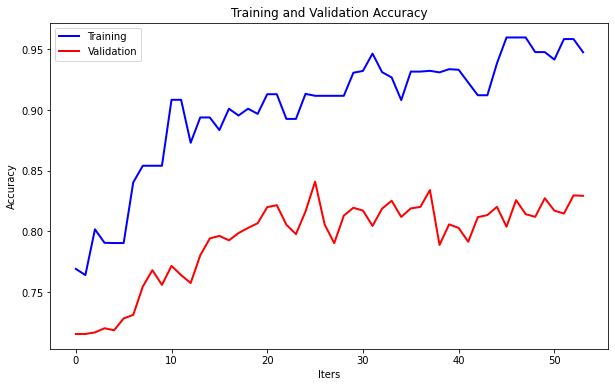

In [11]:
train_val_acc(df['train_bacc'], df['val_bacc'], len(df['epoch']), save=False, fig_name = '/hpc/home/srs108/planetL_binary_acc')

In [12]:
model = CNN().to(device)
model.load_state_dict(torch.load('bal_edit2.pt'))

<All keys matched successfully>

In [ ]:
# def bloom_image_plotting(batch, output_binary, y):
#     import matplotlib.pyplot as plt

#     num_images = len(batch['image'])  # Number of images in the batch
#     rows, cols = 4, 4  # 4x4 grid for a batch of 16 images

#     # Create the figure and axes
#     fig, axes = plt.subplots(rows, cols, figsize=(15, 15))  # Increase the figure size for larger images

#     # Loop through the images and plot
#     for i in range(num_images):
#         row = i // cols  # Determine the row index
#         col = i % cols   # Determine the column index
#         axes[row, col].imshow(batch['image'][i].T)  # Transpose the image for correct orientation
#         axes[row, col].set_title(f'Output: {output_binary[i].item()}, Label: {y[i].item()}')
#         axes[row, col].axis('off')  # Hide axes

#     # Turn off any unused axes if the number of images is less than 16
#     for i in range(num_images, rows * cols):
#         fig.delaxes(axes[i // cols, i % cols])

#     # Tight layout to reduce spacing
#     plt.tight_layout()
#     plt.show()
#     plt.close()


In [25]:
criterion = nn.BCEWithLogitsLoss().to(device)  

model.eval()
running_loss = 0
running_acc = 0
running_bacc = 0

all_labels_for_auc = []
all_outputs_for_auc = []

all_binary_for_cm = []
all_labels_for_cm = []
all_outputs_for_cm = []
test_history = {}

with torch.no_grad():
    for i, batch in tqdm(enumerate(test_loader)):
        x = batch['image'].float().to(device)
        y = batch['class_lbl'].float().to(device) 
        output = model(x)
        output_binary = np.zeros(output.shape)
        output_binary[output.cpu().detach().numpy() >= 0] = 1 #if logit is greater than 0, classify as bloom

        #loss
        loss = criterion(output.squeeze(dim=1),y) #BCEwL
        running_loss += loss.item()

        all_labels_for_auc.append(y.cpu().detach().numpy())
        all_outputs_for_auc.append(output.cpu().detach().numpy())
        
        all_labels_for_cm.extend(y.cpu().detach().numpy().tolist())  # Append only values
        all_outputs_for_cm.extend(output.cpu().detach().numpy().tolist())  # Append only values
        all_binary_for_cm.extend(output_binary.tolist()) 

        # accuracy/balanced accuracy 
        label = y.cpu().detach().numpy()
        acc = accuracy_score(label, output_binary)
        bacc = balanced_accuracy_score(label, output_binary)
        running_bacc += bacc
        running_acc += acc
       
#         bloom_image_plotting(batch, output_binary,y)
        torch.cuda.empty_cache()
# AUC
all_labels_for_auc = np.concatenate(all_labels_for_auc)
all_outputs_for_auc = np.concatenate(all_outputs_for_auc)
auc = roc_auc_score(all_labels_for_auc, all_outputs_for_auc)
fpr, tpr, thresholds = roc_curve(all_labels_for_auc, all_outputs_for_auc)

115it [06:57,  3.63s/it]


In [38]:
rs = pd.read_csv('rs.csv', header = 0)

In [42]:
tpr2 = np.array(rs['tpr'])
fpr2 = np.array(rs['fpr'])
auc2 = 

0.5411772060536829

<Axes: >

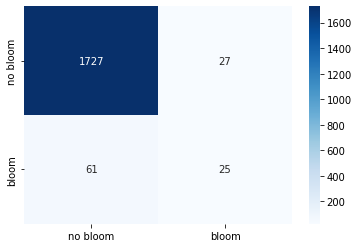

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(all_labels_for_cm, all_binary_for_cm)
sns.heatmap(cm,annot=True,cmap='Blues', fmt='g',xticklabels=['no bloom', 'bloom'], 
            yticklabels=['no bloom', 'bloom'])


In [27]:
def plot_roc_curve(fpr, tpr, auc, save=False):
    fig, ax = plt.subplots(1,1)
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#     plt.xlim([0.0, 1.0])
#     plt.ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize = 14)
    ax.set_ylabel('True Positive Rate', fontsize = 14)
    ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize =15)
    ax.legend(loc="lower right")
    plt.show()
    if save ==True:
        fig.savefig('ROC' + '.png', transparent=False, facecolor = 'white')

0.8547307151759433
Testing Accuracy 0.9521739130434783
Testing Loss 0.1804683776744439


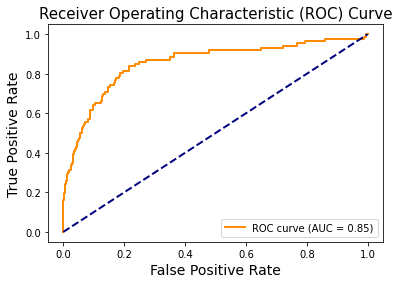

In [29]:
print(auc)

print('Testing Accuracy',running_acc/len(test_loader))
print('Testing Loss',running_loss/len(test_loader))

plot_roc_curve(fpr, tpr, auc, save=True)


In [15]:
# def main(model, epochs):
#     opt                        = optim.Adam(model.parameters(), lr=1e-5)#, momentum=0.9)
#     criterion                  = nn.BCEWithLogitsLoss().to(device)  
#     best_loss                  = 1e6
#     patience                   = np.ceil(0.1*epochs)
#     trigger_times              = 0
#     history = {'epoch':[],'train_loss': [], 'val_loss':[], 'train_acc': [], 'val_acc':[], 'train_bacc':[], 'val_bacc':[]}

#     for epoch in range(5, epochs+1):

#         train_loss, train_acc, train_bacc = train(model,  train_loader, criterion, opt, epoch, device)
#         val_loss, val_acc, val_bacc = test(model, val_loader, criterion, device)

#         if val_loss < best_loss:
#             trigger_times = 0
#             best_loss = val_loss
#             best_model_weights = model.state_dict()
#             torch.save(model.state_dict(), 'bal_edit.pt')

#         else:
#             trigger_times += 1
#             if trigger_times == patience:
#                 print(f"Early stopping on epoch {epoch} - patience reached")
#                 torch.save(model.state_dict(), 'final_weights.pt')
#                 break

#         print(f'Epoch {epoch}\n\tCurrent train/val Loss: {round(train_loss, 5)}/{round(val_loss, 5)}\n\tCurrent train/val Accuracy: {round(train_acc,5)}/{round(val_acc,5)}\n\tCurrent train/val Bal Accuracy: {round(train_bacc,5)}/{round(val_bacc,5)}')

#         if trigger_times != 0:
#             print(f'\tCurrent Triggers: {trigger_times}')

#         history['epoch'].append(epoch)
#         history['train_loss'].append(train_loss)
#         history['train_acc'].append(train_acc)
#         history['val_loss'].append(val_loss)
#         history['val_acc'].append(val_acc)
#         history['train_bacc'].append(train_bacc)
#         history['val_bacc'].append(val_bacc)
#         df = pd.DataFrame(history)
#         df.to_csv('x.csv', index=False)

In [32]:
running_bacc/len(test_loader)

0.8063529224398791

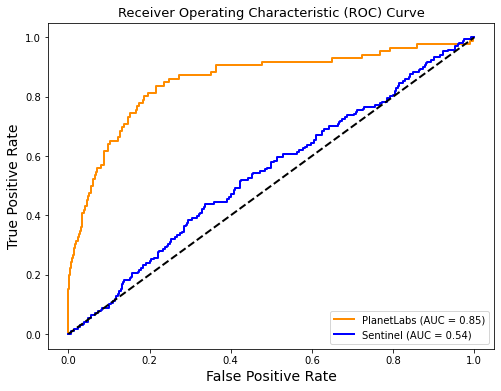

In [60]:
def plot_roc_curve(fpr1, tpr1, auc1, fpr2, tpr2, auc2, save=False):
    fig, ax = plt.subplots(1, 1, figsize = (8,6))
    ax.plot(fpr1, tpr1, color='darkorange', lw=2, label=f'PlanetLabs (AUC = {auc1:.2f})')
    ax.plot(fpr2, tpr2, color='blue', lw=2, label=f'Sentinel (AUC = {auc2:.2f})')
    ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--')
    
    ax.set_xlabel('False Positive Rate', fontsize=14)
    ax.set_ylabel('True Positive Rate', fontsize=14)
    ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=13)
    ax.legend(loc="lower right")
    
    plt.show()
    if save:
        fig.savefig('ROC_comparison.png', transparent=False, facecolor='white')

plot_roc_curve(fpr, tpr, auc, fpr2, tpr2, rs['auc'][0], save = True)

In [46]:
auc2

'auc'

In [61]:
cm

NameError: name 'cm' is not defined